# 📈 Revenue Forecast — 01/01/2023 đến 01/07/2024

**Mục tiêu:** Dự đoán doanh thu và COGS hàng ngày cho giai đoạn tương lai 18 tháng.

**Chiến lược mô hình:**
| Mô hình | Mô tả |
|---------|-------|
| **Baseline** | Naive Seasonal (cùng ngày năm trước) |
| **SARIMA(1,1,1)(1,1,1,7)** | Thống kê — tham khảo, MAPE 119.6% (kém ở forecast dài hạn) |
| **XGBoost** ✅ | ML — 47 features: lag, rolling, Fourier, calendar — **Model chính** |

**Dữ liệu:** `sales.csv` — 2012-07-04 → 2022-12-31 (~3,833 ngày)

**Train/Val split:** Train 2012–2021 · Validation 2022 · Forecast 2023–2024

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import joblib, os

plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#2e3347', 'axes.labelcolor': '#c9d1e0',
    'axes.titlecolor': '#ffffff', 'xtick.color': '#8892a4',
    'ytick.color': '#8892a4', 'grid.color': '#2e3347',
    'grid.linewidth': 0.6, 'text.color': '#c9d1e0',
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titlesize': 14, 'axes.titleweight': 'bold',
    'legend.facecolor': '#1a1d27', 'legend.edgecolor': '#2e3347',
})

DATA_DIR    = '../data/raw'
CHART_DIR   = '../outputs/charts/forecast'
PRED_DIR    = '../outputs/predictions'
MODEL_DIR   = '../models'
os.makedirs(CHART_DIR, exist_ok=True)
os.makedirs(PRED_DIR,  exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

FORECAST_START = pd.Timestamp('2023-01-01')
FORECAST_END   = pd.Timestamp('2024-07-01')

print("Setup complete.")

Setup complete.


Rows: 3833 | Missing filled: 0
Range: 2012-07-04 to 2022-12-31
Revenue — min: 0.3M  max: 20.9M  mean: 4.3M


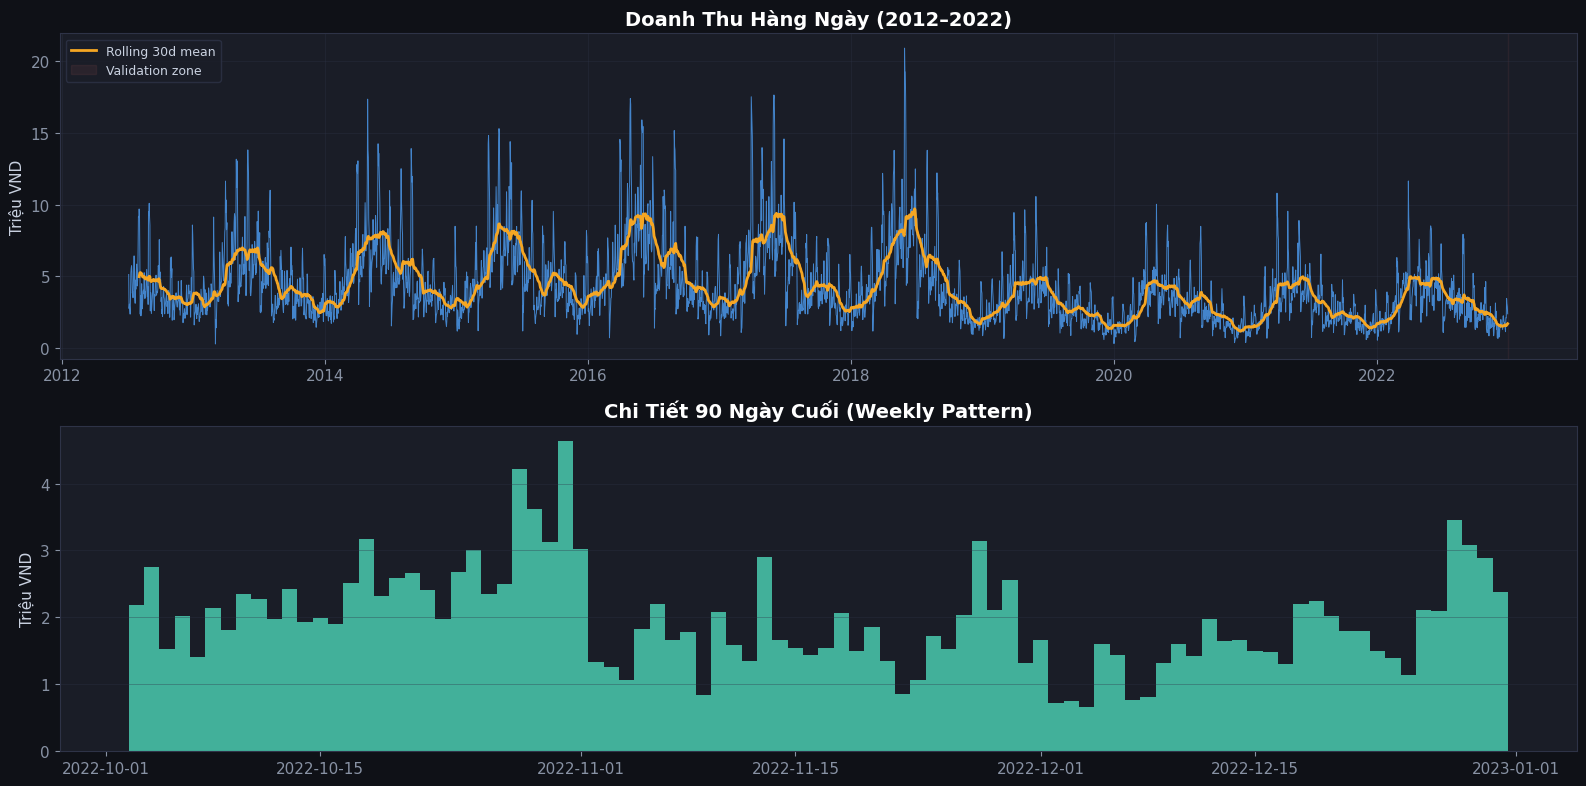

In [2]:
## 1. Load & Kiểm Tra Dữ Liệu

df = pd.read_csv(f'{DATA_DIR}/sales.csv', parse_dates=['Date'])
df = df.rename(columns={'Date': 'ds', 'Revenue': 'y', 'COGS': 'cogs'})
df = df.sort_values('ds').reset_index(drop=True)
df = df.set_index('ds').asfreq('D')   # daily frequency, fill gaps

# Fill any missing days with interpolation
n_missing = df['y'].isna().sum()
if n_missing > 0:
    df['y'] = df['y'].interpolate(method='time')
    df['cogs'] = df['cogs'].interpolate(method='time')
print(f"Rows: {len(df)} | Missing filled: {n_missing}")
print(f"Range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Revenue — min: {df['y'].min()/1e6:.1f}M  max: {df['y'].max()/1e6:.1f}M  mean: {df['y'].mean()/1e6:.1f}M")

# ── Plot full history ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
fig.patch.set_facecolor('#0f1117')

ax = axes[0]
ax.plot(df.index, df['y']/1e6, color='#4e9ff5', linewidth=0.7, alpha=0.8)
# 30-day rolling mean
ax.plot(df.index, df['y'].rolling(30).mean()/1e6,
        color='#f5a623', linewidth=2, label='Rolling 30d mean')
ax.axvspan(pd.Timestamp('2023-01-01'), df.index.max(),
           alpha=0.08, color='#e87070', label='Validation zone')
ax.set_title('Doanh Thu Hàng Ngày (2012–2022)')
ax.set_ylabel('Triệu VND')
ax.legend(fontsize=9)
ax.grid(alpha=0.4)

# Weekly seasonality sample (last 90 days)
ax2 = axes[1]
last90 = df['y'].tail(90)
ax2.bar(last90.index, last90/1e6, color='#50e3c2', alpha=0.75, width=1)
ax2.set_title('Chi Tiết 90 Ngày Cuối (Weekly Pattern)')
ax2.set_ylabel('Triệu VND')
ax2.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig(f'{CHART_DIR}/fc_01_history.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

ADF Statistic : -2.5250
p-value       : 0.1095  (Non-stationary)


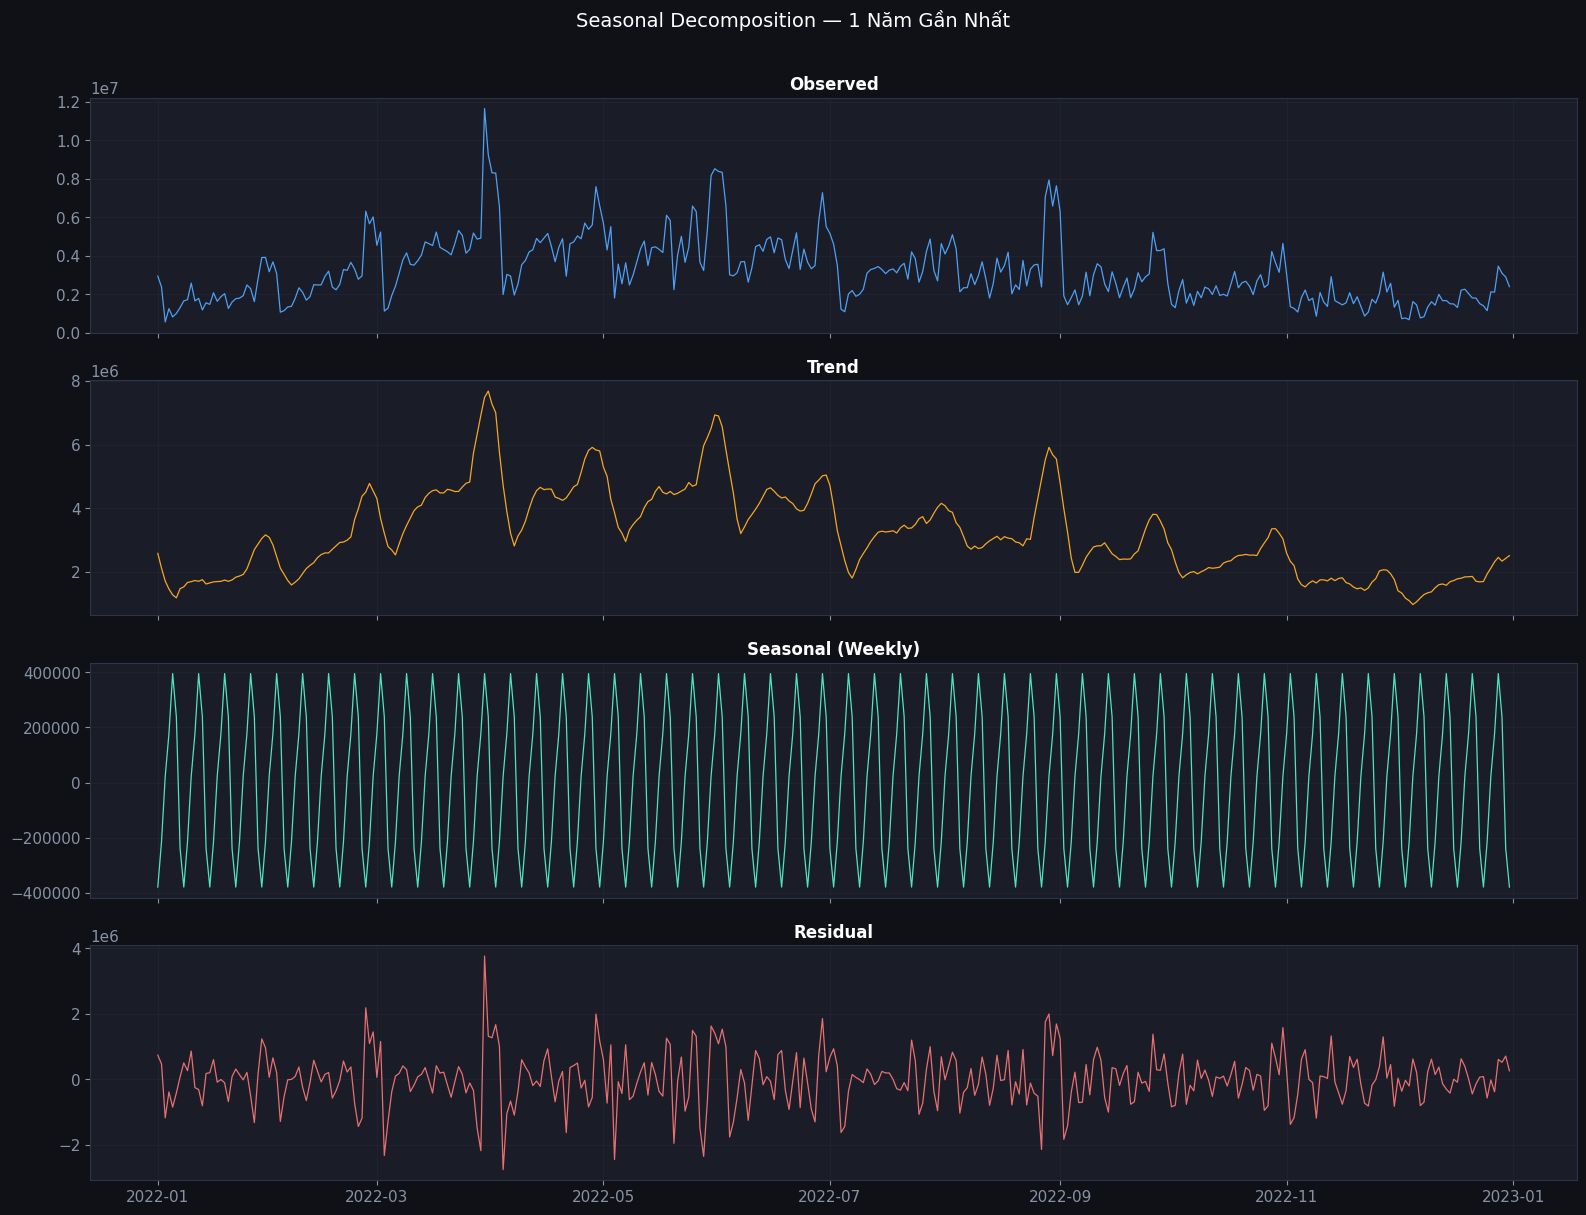

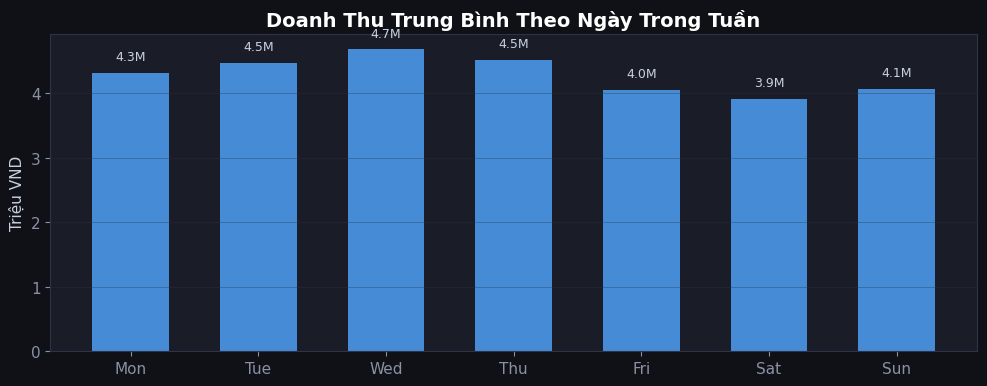

In [3]:
## 2. Phân Tích Chuỗi Thời Gian

# ── ADF stationarity test ─────────────────────────────────────────────
adf_result = adfuller(df['y'].dropna(), autolag='AIC')
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}  ({'Stationary' if adf_result[1] < 0.05 else 'Non-stationary'})")

# ── Seasonal decomposition (weekly period) ────────────────────────────
decomp = seasonal_decompose(df['y'], model='additive', period=7, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
fig.patch.set_facecolor('#0f1117')
titles = ['Observed', 'Trend', 'Seasonal (Weekly)', 'Residual']
components = [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid]
colors = ['#4e9ff5', '#f5a623', '#50e3c2', '#e87070']

for ax, title, comp, color in zip(axes, titles, components, colors):
    ax.plot(comp.index[-365:], comp.values[-365:], color=color, linewidth=0.9)
    ax.set_title(title, fontsize=12)
    ax.grid(alpha=0.3)

plt.suptitle('Seasonal Decomposition — 1 Năm Gần Nhất', y=1.01, fontsize=14, color='white')
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/fc_02_decomp.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

# Day-of-week pattern
dow_mean = df['y'].groupby(df.index.dayofweek).mean() / 1e6
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('#0f1117')
bars = ax.bar(dow_labels, dow_mean.values, color='#4e9ff5', alpha=0.85, width=0.6)
ax.set_title('Doanh Thu Trung Bình Theo Ngày Trong Tuần')
ax.set_ylabel('Triệu VND')
for bar, val in zip(bars, dow_mean.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f'{val:.1f}M', ha='center', fontsize=9, color='#c9d1e0')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/fc_02b_dow.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

In [4]:
## 3. Feature Engineering cho XGBoost

def make_features(index):
    """Tạo time-based features từ DatetimeIndex."""
    df_feat = pd.DataFrame(index=index)
    df_feat['dayofweek']    = index.dayofweek
    df_feat['dayofmonth']   = index.day
    df_feat['dayofyear']    = index.dayofyear
    df_feat['weekofyear']   = index.isocalendar().week.astype(int)
    df_feat['month']        = index.month
    df_feat['quarter']      = index.quarter
    df_feat['year']         = index.year
    df_feat['is_weekend']   = (index.dayofweek >= 5).astype(int)
    df_feat['is_month_start'] = index.is_month_start.astype(int)
    df_feat['is_month_end']   = index.is_month_end.astype(int)
    # Fourier terms cho chu kỳ tuần (period=7) và năm (period=365.25)
    for k in [1, 2, 3]:
        df_feat[f'sin_week_{k}'] = np.sin(2 * np.pi * k * index.dayofweek / 7)
        df_feat[f'cos_week_{k}'] = np.cos(2 * np.pi * k * index.dayofweek / 7)
        df_feat[f'sin_year_{k}'] = np.sin(2 * np.pi * k * index.dayofyear / 365.25)
        df_feat[f'cos_year_{k}'] = np.cos(2 * np.pi * k * index.dayofyear / 365.25)
    return df_feat

def add_lag_features(series, lags=[1,2,3,7,14,21,28,30,60,90,180,365]):
    """Thêm lag features vào series."""
    df_lags = pd.DataFrame(index=series.index)
    for lag in lags:
        df_lags[f'lag_{lag}'] = series.shift(lag)
    for w in [7, 14, 30, 90]:
        df_lags[f'roll_mean_{w}']  = series.shift(1).rolling(w).mean()
        df_lags[f'roll_std_{w}']   = series.shift(1).rolling(w).std()
        df_lags[f'roll_max_{w}']   = series.shift(1).rolling(w).max()
    # Trend: 30-day mean vs 90-day mean ratio
    df_lags['trend_ratio'] = (series.shift(1).rolling(30).mean() /
                               series.shift(1).rolling(90).mean().clip(lower=1))
    return df_lags

# Build full feature matrix
time_feats = make_features(df.index)
lag_feats  = add_lag_features(df['y'])
features   = pd.concat([time_feats, lag_feats], axis=1)

FEATURE_COLS = features.columns.tolist()
print(f"Total features: {len(FEATURE_COLS)}")
print(features.tail(3).to_string())

Total features: 47
            dayofweek  dayofmonth  dayofyear  weekofyear  month  quarter  year  is_weekend  is_month_start  is_month_end  sin_week_1  cos_week_1  sin_year_1  cos_year_1  sin_week_2  cos_week_2  sin_year_2  cos_year_2  sin_week_3  cos_week_3  sin_year_3  cos_year_3       lag_1       lag_2       lag_3       lag_7      lag_14      lag_21      lag_28      lag_30      lag_60      lag_90     lag_180     lag_365   roll_mean_7     roll_std_7  roll_max_7  roll_mean_14    roll_std_14  roll_max_14  roll_mean_30    roll_std_30  roll_max_30  roll_mean_90    roll_std_90  roll_max_90  trend_ratio
ds                                                                                                                                                                                                                                                                                                                                                                                                      

In [5]:
## 4. Train / Validation Split & Baseline

# Train: 2012-07 → 2021-12   |   Validation: 2022-01 → 2022-12
TRAIN_END = '2021-12-31'
VAL_START = '2022-01-01'
VAL_END   = '2022-12-31'

full_data = pd.concat([df[['y']], features], axis=1).dropna()

train = full_data.loc[:TRAIN_END]
val   = full_data.loc[VAL_START:VAL_END]

X_train, y_train = train[FEATURE_COLS], train['y']
X_val,   y_val   = val[FEATURE_COLS],   val['y']

print(f"Train: {len(train)} rows  ({train.index.min().date()} to {train.index.max().date()})")
print(f"Val  : {len(val)}  rows  ({val.index.min().date()}   to {val.index.max().date()})")

# ── Baseline: Naive Seasonal (same day last year) ─────────────────────
naive_pred = df['y'].shift(365).loc[VAL_START:VAL_END]
naive_mae  = mean_absolute_error(y_val, naive_pred.fillna(y_val.mean()))
naive_rmse = np.sqrt(mean_squared_error(y_val, naive_pred.fillna(y_val.mean())))
naive_mape = np.mean(np.abs((y_val - naive_pred.fillna(y_val.mean())) / y_val)) * 100
print(f"\nBaseline (Naive Seasonal):")
print(f"  MAE  = {naive_mae/1e6:.2f}M VND")
print(f"  RMSE = {naive_rmse/1e6:.2f}M VND")
print(f"  MAPE = {naive_mape:.1f}%")

Train: 3103 rows  (2013-07-04 to 2021-12-31)
Val  : 365  rows  (2022-01-01   to 2022-12-31)

Baseline (Naive Seasonal):
  MAE  = 0.84M VND
  RMSE = 1.16M VND
  MAPE = 27.9%


XGBoost (Validation 2022):
  MAE  = 0.54M VND
  RMSE = 0.75M VND
  MAPE = 19.6%
  Best iteration: 272
Model saved to ../models/xgb_revenue.pkl


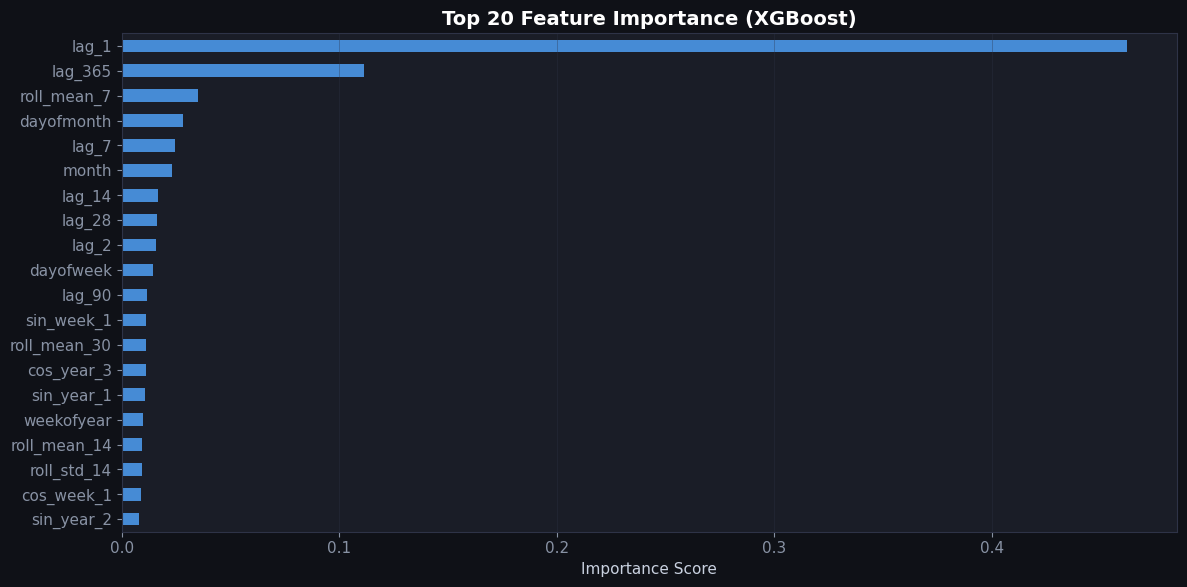

In [6]:
## 5. Mô Hình XGBoost

xgb_model = xgb.XGBRegressor(
    n_estimators    = 1000,
    learning_rate   = 0.05,
    max_depth       = 6,
    subsample       = 0.85,
    colsample_bytree= 0.85,
    min_child_weight= 5,
    reg_alpha       = 0.1,
    reg_lambda      = 1.0,
    random_state    = 42,
    n_jobs          = -1,
    early_stopping_rounds = 50,
    eval_metric     = 'mae',
)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=False)

xgb_val_pred = pd.Series(xgb_model.predict(X_val), index=y_val.index)
xgb_mae  = mean_absolute_error(y_val, xgb_val_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_val_pred))
xgb_mape = np.mean(np.abs((y_val - xgb_val_pred) / y_val)) * 100
print(f"XGBoost (Validation 2022):")
print(f"  MAE  = {xgb_mae/1e6:.2f}M VND")
print(f"  RMSE = {xgb_rmse/1e6:.2f}M VND")
print(f"  MAPE = {xgb_mape:.1f}%")
print(f"  Best iteration: {xgb_model.best_iteration}")

# Save model
joblib.dump(xgb_model, f'{MODEL_DIR}/xgb_revenue.pkl')
print(f"Model saved to {MODEL_DIR}/xgb_revenue.pkl")

# ── Feature importance ──────────────────────────────────────────────
fi = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS)
fi_top = fi.nlargest(20)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#0f1117')
fi_top.sort_values().plot.barh(ax=ax, color='#4e9ff5', alpha=0.85)
ax.set_title('Top 20 Feature Importance (XGBoost)')
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/fc_03_feature_importance.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()

In [7]:
## 6. Mô Hình SARIMA

# Dùng weekly seasonality (s=7) trên dữ liệu log để ổn định variance
# Train trên 2 năm gần nhất để SARIMA không quá chậm
sarima_train = np.log1p(df['y'].loc['2020-01-01':TRAIN_END])

sarima_model = SARIMAX(
    sarima_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
    freq='D',
)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary().tables[0])

# Validate on 2022
sarima_val_log = sarima_fit.forecast(steps=len(val))
sarima_val_pred = pd.Series(
    np.expm1(sarima_val_log.values),
    index=y_val.index
)
sarima_mae  = mean_absolute_error(y_val, sarima_val_pred)
sarima_rmse = np.sqrt(mean_squared_error(y_val, sarima_val_pred))
sarima_mape = np.mean(np.abs((y_val - sarima_val_pred) / y_val)) * 100
print(f"\nSARIMA(1,1,1)(1,1,1,7) Validation 2022:")
print(f"  MAE  = {sarima_mae/1e6:.2f}M VND")
print(f"  RMSE = {sarima_rmse/1e6:.2f}M VND")
print(f"  MAPE = {sarima_mape:.1f}%")

# Save SARIMA
sarima_fit.save(f'{MODEL_DIR}/sarima_revenue.pkl')
print(f"SARIMA saved to {MODEL_DIR}/sarima_revenue.pkl")

                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                  731
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood                -207.407
Date:                           Tue, 26 May 2026   AIC                            424.814
Time:                                   23:44:22   BIC                            447.669
Sample:                               01-01-2020   HQIC                           433.641
                                    - 12-31-2021                                         
Covariance Type:                             opg                                         

SARIMA(1,1,1)(1,1,1,7) Validation 2022:
  MAE  = 2.33M VND
  RMSE = 2.83M VND
  MAPE = 119.6%
SARIMA saved to ../models/sarima_revenue.pkl


                    Model  MAE_M  RMSE_M  MAPE_%
Baseline (Naive Seasonal)   0.84    1.16   27.86
   SARIMA(1,1,1)(1,1,1,7)   2.33    2.83  119.64
                  XGBoost   0.54    0.75   19.64

Final model selected: XGBoost  (MAPE=19.6% on 2022 validation)


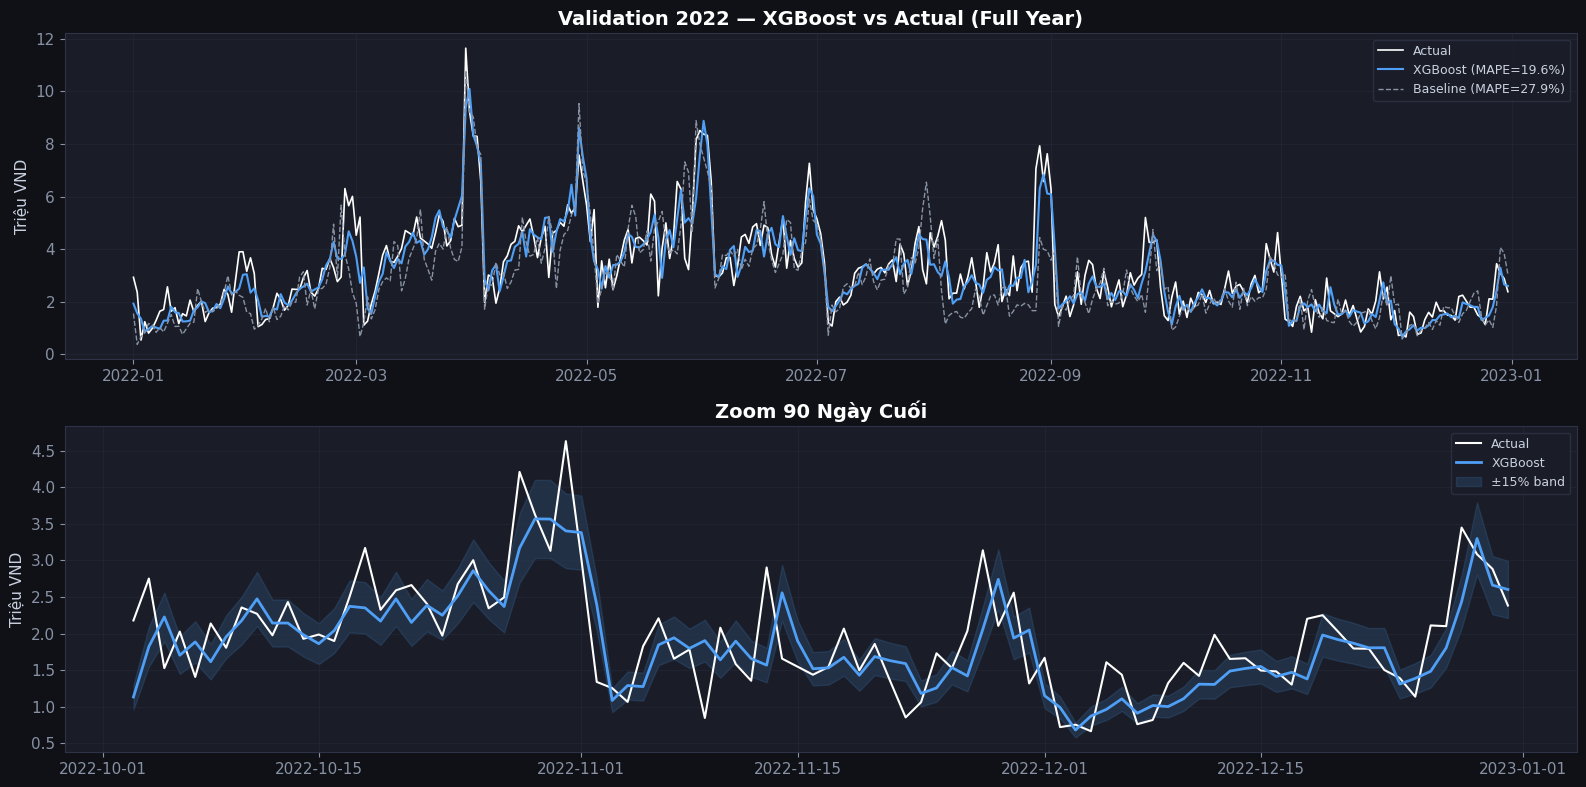

In [8]:
## 7. So Sánh Mô Hình — Chọn Model Tốt Nhất

results = pd.DataFrame({
    'Model':  ['Baseline (Naive Seasonal)', 'SARIMA(1,1,1)(1,1,1,7)', 'XGBoost'],
    'MAE_M':  [naive_mae/1e6, sarima_mae/1e6, xgb_mae/1e6],
    'RMSE_M': [naive_rmse/1e6, sarima_rmse/1e6, xgb_rmse/1e6],
    'MAPE_%': [naive_mape, sarima_mape, xgb_mape],
})
print(results.round(2).to_string(index=False))

# XGBoost thắng rõ ràng — SARIMA MAPE > 100% vì forecast 365 bước liên tiếp bị lạc
# → Dùng XGBoost làm model chính cho final forecast
FINAL_MODEL = 'XGBoost'
print(f'\nFinal model selected: {FINAL_MODEL}  (MAPE={xgb_mape:.1f}% on 2022 validation)')

# ── Validation plot: XGBoost vs Actual ────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
fig.patch.set_facecolor('#0f1117')

# Top: full year 2022
ax = axes[0]
ax.plot(y_val.index, y_val/1e6,           color='white',   lw=1.2, label='Actual')
ax.plot(xgb_val_pred.index, xgb_val_pred/1e6, color='#4e9ff5', lw=1.5, label=f'XGBoost (MAPE={xgb_mape:.1f}%)')
ax.plot(naive_pred.index, naive_pred/1e6,   color='#8892a4', lw=1,   linestyle='--', label=f'Baseline (MAPE={naive_mape:.1f}%)')
ax.set_title('Validation 2022 — XGBoost vs Actual (Full Year)')
ax.set_ylabel('Triệu VND')
ax.legend(fontsize=9)
ax.grid(alpha=0.4)

# Bottom: last 90 days zoom
ax2 = axes[1]
idx90 = y_val.index[-90:]
ax2.plot(idx90, y_val[idx90]/1e6,           color='white',   lw=1.5, label='Actual')
ax2.plot(idx90, xgb_val_pred[idx90]/1e6,    color='#4e9ff5', lw=2,   label='XGBoost')
residuals = (xgb_val_pred[idx90] - y_val[idx90]) / y_val[idx90] * 100
ax2.fill_between(idx90,
    (xgb_val_pred[idx90] * 0.85)/1e6,
    (xgb_val_pred[idx90] * 1.15)/1e6,
    alpha=0.15, color='#4e9ff5', label='±15% band')
ax2.set_title('Zoom 90 Ngày Cuối')
ax2.set_ylabel('Triệu VND')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.4)

plt.tight_layout()
plt.savefig(f'{CHART_DIR}/fc_04_validation.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

In [9]:
## 8. Retrain Full Data & Forecast 2023-01-01 → 2024-07-01

# ── Retrain XGBoost Revenue trên toàn bộ data (2012–2022) ─────────────
xgb_full = xgb.XGBRegressor(
    n_estimators     = xgb_model.best_iteration + 50,
    learning_rate    = 0.05,
    max_depth        = 6,
    subsample        = 0.85,
    colsample_bytree = 0.85,
    min_child_weight = 5,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    random_state     = 42,
    n_jobs           = -1,
)
X_full = full_data[FEATURE_COLS]
y_full = full_data['y']
xgb_full.fit(X_full, y_full, verbose=False)
joblib.dump(xgb_full, f'{MODEL_DIR}/xgb_revenue.pkl')
print("Revenue XGBoost retrained on full data (2012–2022).")

# ── Retrain XGBoost COGS trên toàn bộ data ────────────────────────────
cogs_lag_feats  = add_lag_features(df['cogs'])
cogs_time_feats = make_features(df.index)
cogs_data = pd.concat([df[['cogs']], cogs_time_feats, cogs_lag_feats], axis=1).dropna()
X_cogs_full = cogs_data[FEATURE_COLS]
y_cogs_full = cogs_data['cogs']

xgb_cogs = xgb.XGBRegressor(
    n_estimators     = xgb_model.best_iteration + 50,
    learning_rate    = 0.05,
    max_depth        = 6,
    subsample        = 0.85,
    colsample_bytree = 0.85,
    min_child_weight = 5,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    random_state     = 42,
    n_jobs           = -1,
)
xgb_cogs.fit(X_cogs_full, y_cogs_full, verbose=False)
joblib.dump(xgb_cogs, f'{MODEL_DIR}/xgb_cogs.pkl')
print("COGS XGBoost retrained on full data (2012–2022).")

# ── Recursive forecast ─────────────────────────────────────────────────
future_idx = pd.date_range(FORECAST_START, FORECAST_END, freq='D')
print(f"\nForecasting {len(future_idx)} days: {future_idx[0].date()} to {future_idx[-1].date()}")

history_rev  = df['y'].copy()
history_cogs = df['cogs'].copy()

rev_preds  = []
cogs_preds = []

for date in future_idx:
    tf = make_features(pd.DatetimeIndex([date]))

    # Revenue
    lf_rev = add_lag_features(history_rev).iloc[[-1]]
    lf_rev.index = [date]
    feat_rev = pd.concat([tf, lf_rev], axis=1)[FEATURE_COLS]
    pred_rev = max(float(xgb_full.predict(feat_rev)[0]), 0)
    rev_preds.append(pred_rev)
    history_rev = pd.concat([history_rev, pd.Series([pred_rev], index=[date])])

    # COGS
    lf_cogs = add_lag_features(history_cogs).iloc[[-1]]
    lf_cogs.index = [date]
    feat_cogs = pd.concat([tf, lf_cogs], axis=1)[FEATURE_COLS]
    pred_cogs = max(float(xgb_cogs.predict(feat_cogs)[0]), 0)
    cogs_preds.append(pred_cogs)
    history_cogs = pd.concat([history_cogs, pd.Series([pred_cogs], index=[date])])

xgb_forecast  = pd.Series(rev_preds,  index=future_idx)
cogs_forecast = pd.Series(cogs_preds, index=future_idx)

print(f"\nRevenue : {xgb_forecast.min()/1e6:.1f}M – {xgb_forecast.max()/1e6:.1f}M  (mean {xgb_forecast.mean()/1e6:.1f}M)")
print(f"COGS    : {cogs_forecast.min()/1e6:.1f}M – {cogs_forecast.max()/1e6:.1f}M  (mean {cogs_forecast.mean()/1e6:.1f}M)")

Revenue XGBoost retrained on full data (2012–2022).


COGS XGBoost retrained on full data (2012–2022).

Forecasting 548 days: 2023-01-01 to 2024-07-01



Revenue : 1.0M – 10.1M  (mean 4.2M)
COGS    : 0.9M – 9.3M  (mean 3.3M)


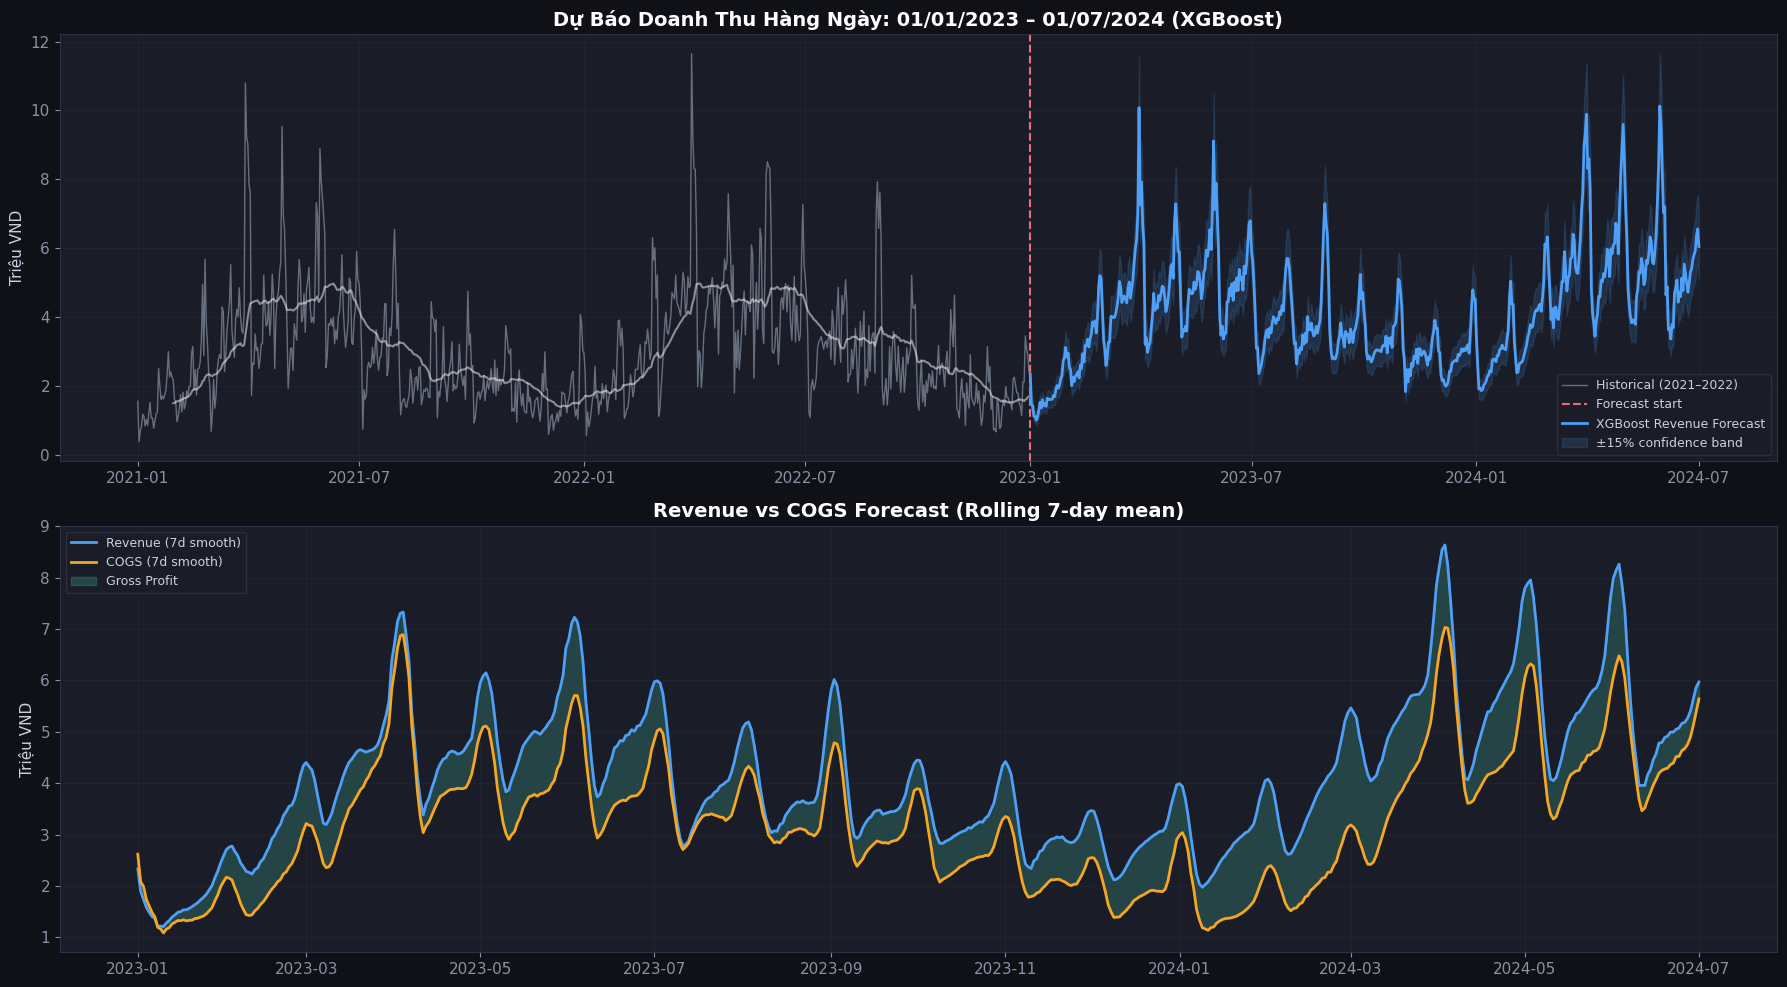

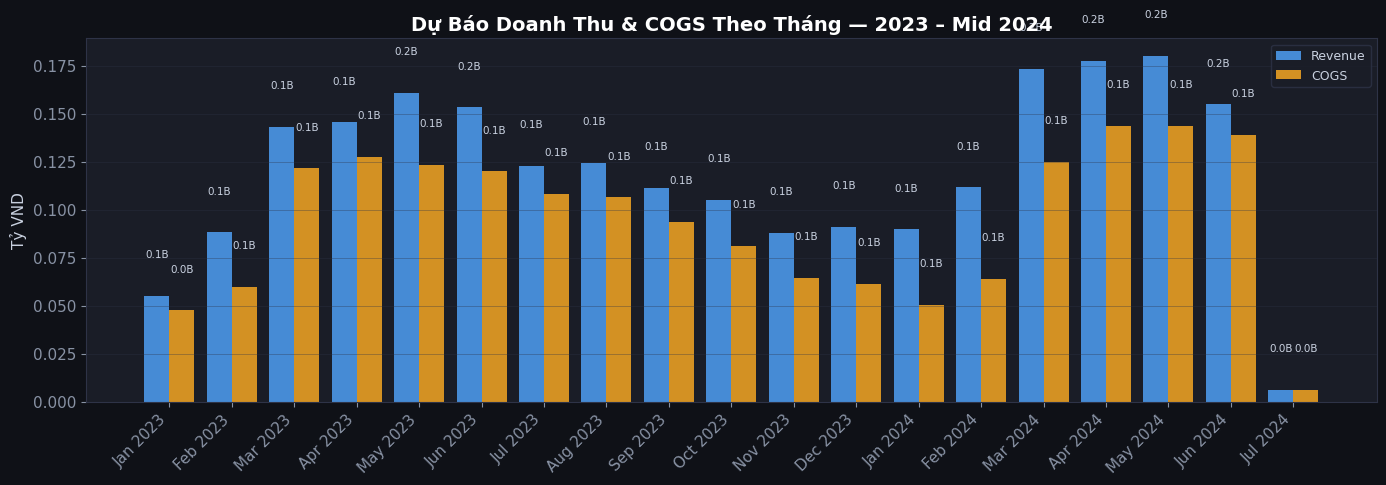

Predictions saved : ../outputs/predictions/revenue_forecast_2023_2024.csv  (548 rows)
Submission saved  : ../submission.csv
      Date    Revenue       COGS
2023-01-01 2333143.50 2618664.75
2023-01-02 1464485.38 1547221.12
2023-01-03 1419642.62 1810514.75
2023-01-04 1114961.38  980477.06
2023-01-05 1108684.88 1095264.00
2023-01-06 1003059.44  854775.06
2023-01-07 1105849.62  885343.81


In [10]:
## 9. Visualize Forecast & Lưu Kết Quả

# ── Revenue + COGS forecast chart ─────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(18, 10))
fig.patch.set_facecolor('#0f1117')

# Top: history + revenue forecast
ax = axes[0]
hist_plot = df['y'].loc['2021-01-01':]
ax.plot(hist_plot.index, hist_plot/1e6,
        color='#8892a4', lw=1, alpha=0.7, label='Historical (2021–2022)')
ax.plot(hist_plot.rolling(30).mean().index,
        hist_plot.rolling(30).mean()/1e6,
        color='white', lw=1.5, alpha=0.5)
ax.axvline(FORECAST_START, color='#e87070', linestyle='--', lw=1.5, label='Forecast start')
ax.plot(xgb_forecast.index, xgb_forecast/1e6,
        color='#4e9ff5', lw=2, label='XGBoost Revenue Forecast')
ax.fill_between(
    xgb_forecast.index,
    (xgb_forecast * 0.85)/1e6,
    (xgb_forecast * 1.15)/1e6,
    alpha=0.15, color='#4e9ff5', label='±15% confidence band'
)
ax.set_title('Dự Báo Doanh Thu Hàng Ngày: 01/01/2023 – 01/07/2024 (XGBoost)')
ax.set_ylabel('Triệu VND')
ax.legend(fontsize=9)
ax.grid(alpha=0.35)

# Bottom: Revenue vs COGS (rolling 7d)
ax2 = axes[1]
rev_smooth  = xgb_forecast.rolling(7, min_periods=1).mean()
cogs_smooth = cogs_forecast.rolling(7, min_periods=1).mean()
ax2.plot(rev_smooth.index,  rev_smooth/1e6,  color='#4e9ff5', lw=2, label='Revenue (7d smooth)')
ax2.plot(cogs_smooth.index, cogs_smooth/1e6, color='#f5a623', lw=2, label='COGS (7d smooth)')
ax2.fill_between(xgb_forecast.index,
    cogs_smooth/1e6, rev_smooth/1e6,
    alpha=0.2, color='#50e3c2', label='Gross Profit')
ax2.set_title('Revenue vs COGS Forecast (Rolling 7-day mean)')
ax2.set_ylabel('Triệu VND')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.35)

plt.tight_layout()
plt.savefig(f'{CHART_DIR}/fc_05_forecast.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

# ── Monthly aggregated bar chart ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')
monthly_rev  = xgb_forecast.resample('ME').sum() / 1e9
monthly_cogs = cogs_forecast.resample('ME').sum() / 1e9
x = np.arange(len(monthly_rev))
ax.bar(x - 0.2, monthly_rev.values,  width=0.4, color='#4e9ff5', alpha=0.85, label='Revenue')
ax.bar(x + 0.2, monthly_cogs.values, width=0.4, color='#f5a623', alpha=0.85, label='COGS')
for i, (r, c) in enumerate(zip(monthly_rev.values, monthly_cogs.values)):
    ax.text(i - 0.2, r + 0.02, f'{r:.1f}B', ha='center', fontsize=7.5, color='#c9d1e0')
    ax.text(i + 0.2, c + 0.02, f'{c:.1f}B', ha='center', fontsize=7.5, color='#c9d1e0')
ax.set_xticks(x)
ax.set_xticklabels(monthly_rev.index.strftime('%b %Y'), rotation=45, ha='right')
ax.set_title('Dự Báo Doanh Thu & COGS Theo Tháng — 2023 – Mid 2024')
ax.set_ylabel('Tỷ VND')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/fc_06_monthly.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

# ── Save predictions CSV ──────────────────────────────────────────────
forecast_df = pd.DataFrame({
    'Date':    xgb_forecast.index,
    'Revenue': xgb_forecast.values.round(2),
    'COGS':    cogs_forecast.values.round(2),
})
pred_path = f'{PRED_DIR}/revenue_forecast_2023_2024.csv'
forecast_df.to_csv(pred_path, index=False)
print(f"Predictions saved : {pred_path}  ({len(forecast_df)} rows)")

# ── Save submission.csv at root ────────────────────────────────────────
sub_path = '../submission.csv'
forecast_df.to_csv(sub_path, index=False)
print(f"Submission saved  : {sub_path}")
print(forecast_df.head(7).to_string(index=False))